### Imports

In [ ]:
import numpy as np
import scipy  
import astropy
import matplotlib.pyplot as plt
from astropy.io import fits
import glob

### Let's also generate some fake data.

In [ ]:
import importlib
import fake_data as fd
importlib.reload(fd)

fd.generate_all("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/fake_data")

### A. Measuring the Bias and Read Noise

Bias level (mean of means): 592.3481310388712
Read noise (mean of stds): 23.610979895006835
Std of means (frame-to-frame bias stability): 0.34497841969507836
Std of stds (frame-to-frame noise consistency): 0.03628486813161773


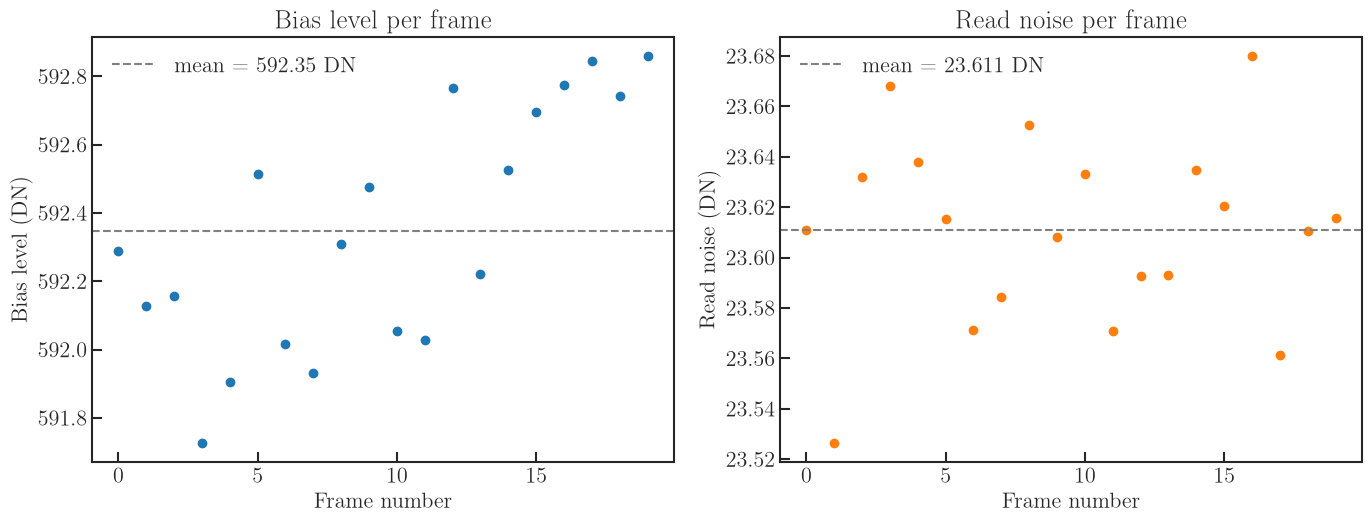

In [25]:
import importlib
import bias_and_read_noise as brn
importlib.reload(brn)

brn.compute_bias_and_read_noise("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/real_data/section_A")

### B. Linearity and Saturation

Loaded 12 frames, exposure times (s): [0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011 0.012]
Centroid: (337.59, 277.77)

 exptime (s)    peak (DN)    aperture sum (DN)         flag
       0.001       4002.0            -161252.6    short-exp
       0.002      10235.0            -116212.6    short-exp
       0.003      16451.0             -69987.6    short-exp
       0.004      22319.0             -27761.6    short-exp
       0.005      28202.0              11377.4    short-exp
       0.006      34732.0              61059.4    short-exp
       0.007      40196.0              99741.4    short-exp
       0.008      45168.0             140330.4    short-exp
       0.009      51258.0             191620.4     near-sat
       0.010      57196.0             231862.4     near-sat
       0.011      62604.0             273195.4     near-sat
       0.012      65534.0             316421.4    SATURATED


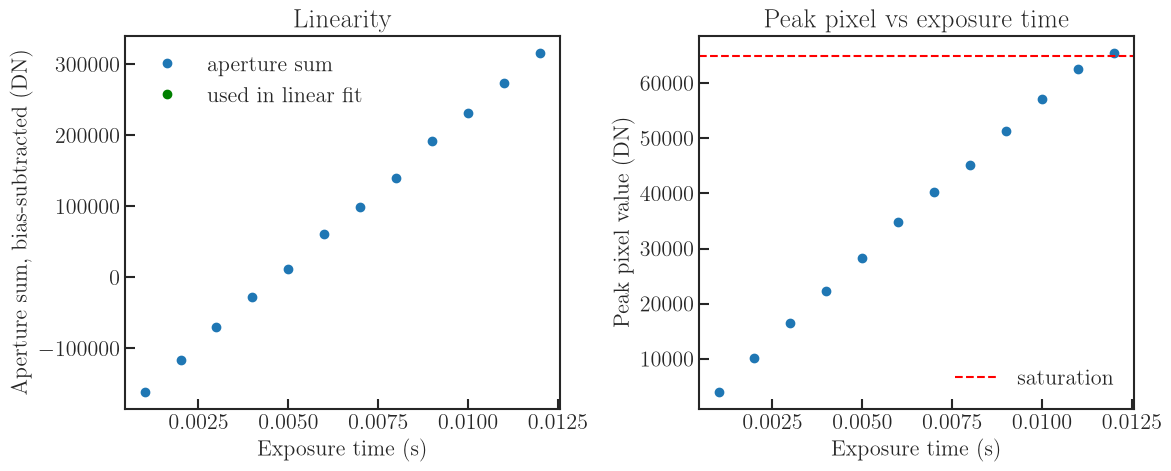

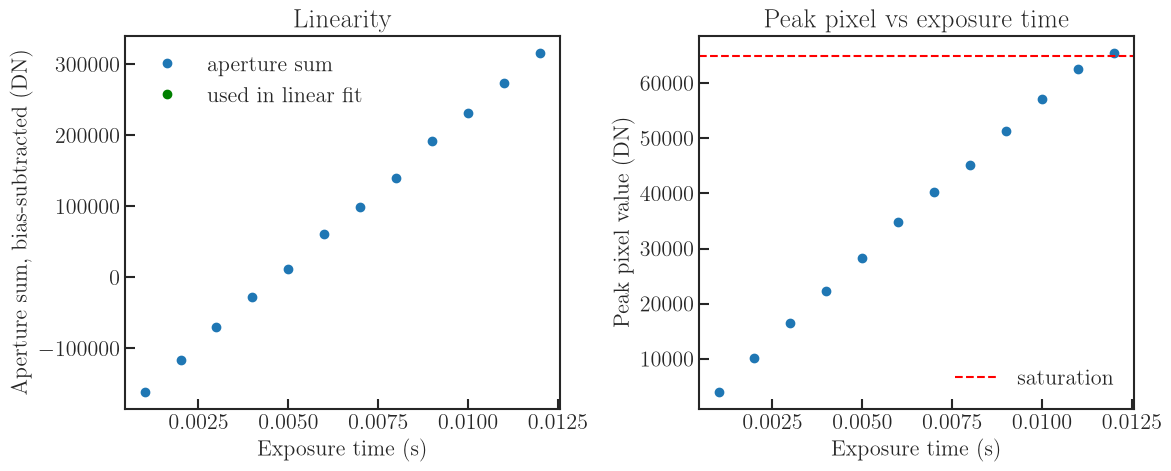

In [36]:
import importlib
import linearity_and_saturation as ls
importlib.reload(ls)

results = ls.analyze_linearity("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/real_data/section_B/f22", 
                                bias_level=592.35)
ls.plot_linearity(results)

### C. Dark Current

Loaded 15 frames, exposure times (s): [1.0e-01 1.0e-01 1.0e-01 1.0e+00 1.0e+00 1.0e+00 5.0e+00 5.0e+00 5.0e+00
 2.0e+01 2.0e+01 2.0e+01 6.0e+01 1.2e+02 3.0e+02]

Single pixel (329, 246): slope = 0.0077 DN/s, intercept = 631.3 DN
Region median: slope = 0.0586 DN/s, intercept = 628.4 DN
Loaded 15 frames, exposure times (s): [1.0e-01 1.0e-01 1.0e-01 1.0e+00 1.0e+00 1.0e+00 5.0e+00 5.0e+00 5.0e+00
 2.0e+01 2.0e+01 2.0e+01 6.0e+01 1.2e+02 3.0e+02]

Single pixel (329, 246): slope = 0.0268 DN/s, intercept = 700.4 DN
Region median: slope = 0.0556 DN/s, intercept = 702.5 DN


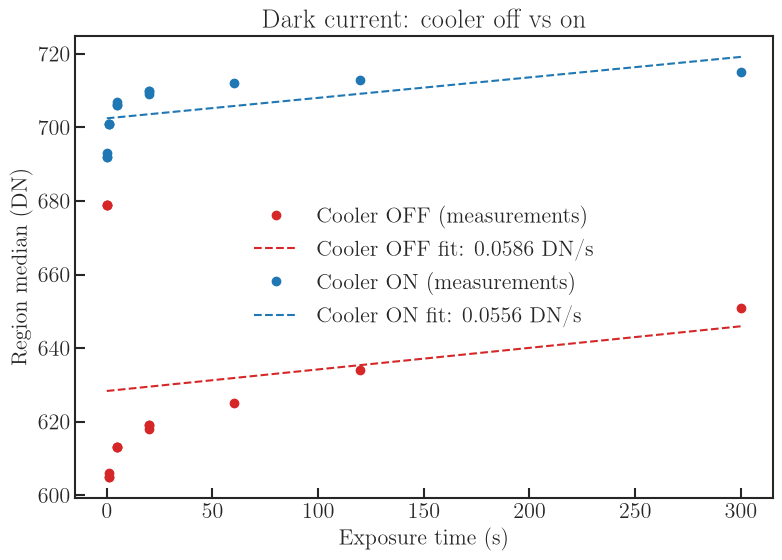

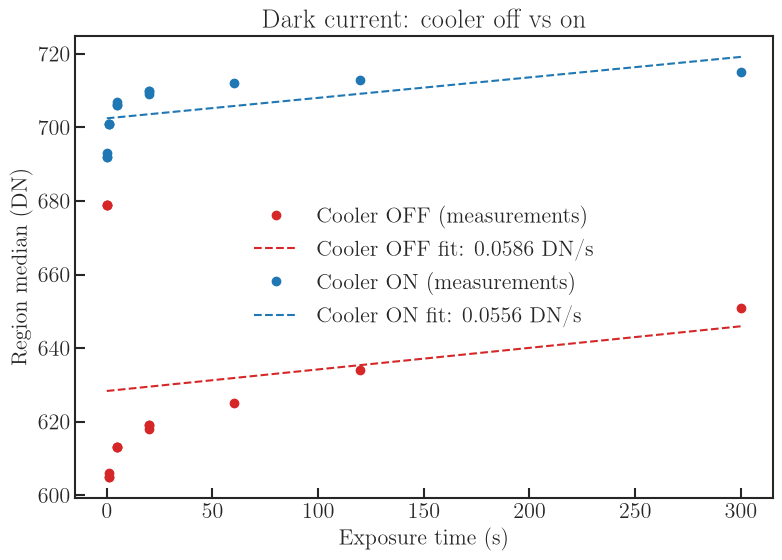

In [34]:
import importlib
import dark_current as dc
importlib.reload(dc)

off_results = dc.analyze_dark_current("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/real_data/section_C/Cooler Inactive")
on_results = dc.analyze_dark_current("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/real_data/section_C/Cooler Active")

dc.plot_comparison(off_results, on_results)

### D. DN-to-electrons

Loaded 11 frames, exposure times (s): [1.e-01 2.e-01 5.e-01 1.e+00 2.e+00 5.e+00 1.e+01 2.e+01 5.e+01 1.e+02
 2.e+02]

 exptime (s)    signal (DN)   noise (DN)  shot noise (DN)           regime
       0.100          161.2        27.87            14.81                 
       0.200          258.1        33.29            23.47                 
       0.500          426.6        40.77            33.24       shot noise
       1.000          684.2        49.85            43.90       shot noise
       2.000         1195.1        64.64            60.18       shot noise
       5.000         2726.9        96.68            93.76       shot noise
      10.000         5241.2       134.31           132.22       shot noise
      20.000        10422.8       190.88           189.41       shot noise
      50.000        25292.8       309.58           308.68       shot noise
     100.000        49611.7       454.73           454.12                 
     200.000        64196.9      1110.75          1110.5

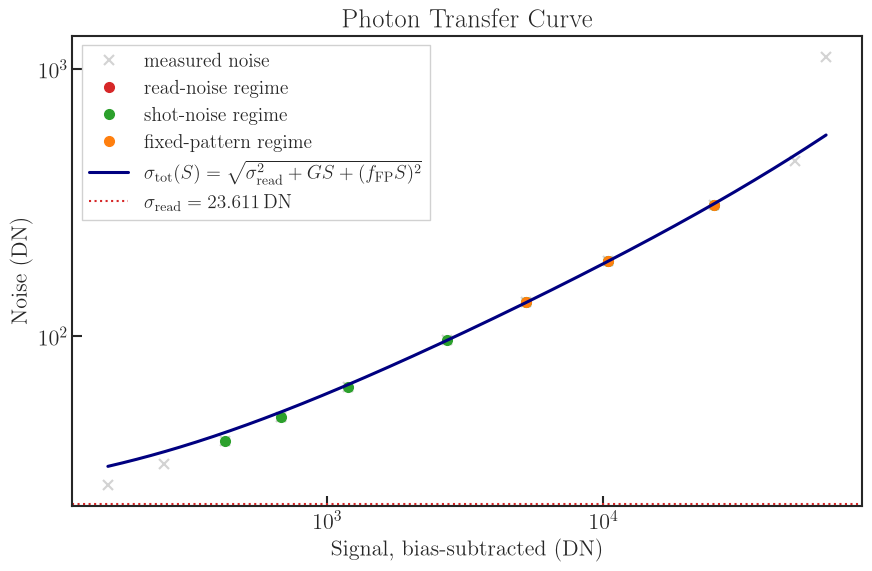

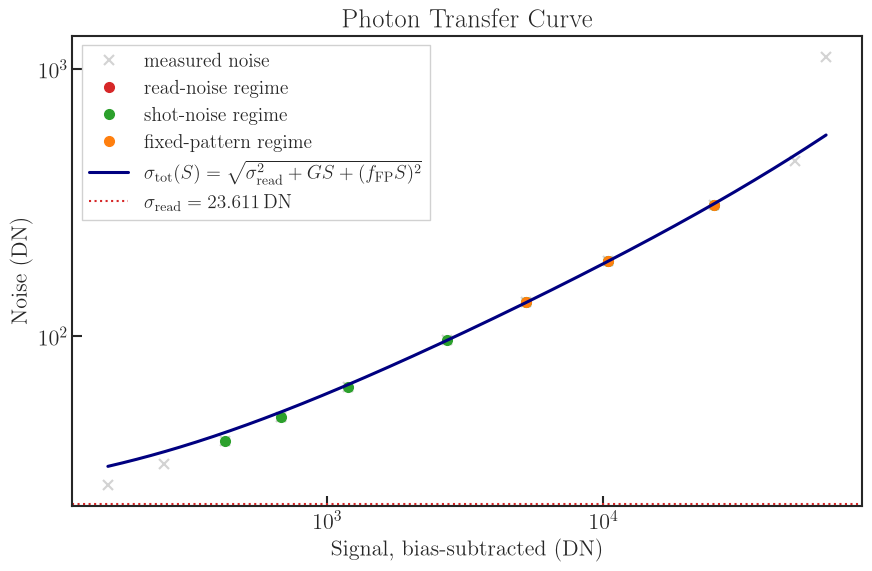

In [32]:
import importlib
import photon_transfer as pt
importlib.reload(pt)

results = pt.analyze_photon_transfer(
    "/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/real_data/section_D",
    bias_level=592.3481310388712,         # from Section A 
    read_noise_dn=23.610979895006835,      # from Section A 
)
pt.plot_ptc(results)

### E. Cosmic Rays

In [ ]:
import importlib
import cosmic_rays as cs
importlib.reload(cs)

cs.full_analyze(
    andor_dir="/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/AndorCCD-CosmicRays",
    atik_dir="/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/CRtest",
    output_dir="/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/plots",
)